# Custom datasets

In [2]:
import torch
from torch import nn
device = 'mps' if torch.mps.is_available() else 'cpu'
device

'mps'

# Get data
subset of Food101 with 3 classes

In [3]:
import requests
import zipfile
from pathlib import Path

data_path = Path('data')
image_path = data_path / 'pizza_steak_sushi'

if image_path.is_dir():
    print(f'{image_path} already exists, skipping download.')
else:
    print(f'Downloading and extracting data to {data_path}...')
    image_path.mkdir(parents=True, exist_ok=True)

# Download the zip file
with open(data_path / 'pizza_steak_sushi.zip', 'wb') as f:
    request = requests.get('https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip')
    print(f'Downloading: {request.status_code}')
    f.write(request.content)
    print('Download complete.')

# Extract the zip file
with zipfile.ZipFile(data_path / 'pizza_steak_sushi.zip', 'r') as zip_ref:
    print('Extracting files...')
    zip_ref.extractall(image_path)
    print('Extraction complete.')

Downloading: 200
Download complete.
Extracting files...
Extraction complete.


# 2. Becoming one with the data

In [5]:
import os
def walk_through_dir(dir_path):
    """Walks through dir_path returning its contents."""
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f'Found directory: {len(dirpath)}')
        print(f'Contains subdirectories: {len(dirnames)}')
        print(f'Contains files: {len(filenames)}')
        print('---')
walk_through_dir(image_path)

Found directory: 22
Contains subdirectories: 2
Contains files: 0
---
Found directory: 27
Contains subdirectories: 3
Contains files: 0
---
Found directory: 33
Contains subdirectories: 0
Contains files: 19
---
Found directory: 33
Contains subdirectories: 0
Contains files: 31
---
Found directory: 33
Contains subdirectories: 0
Contains files: 25
---
Found directory: 28
Contains subdirectories: 3
Contains files: 0
---
Found directory: 34
Contains subdirectories: 0
Contains files: 75
---
Found directory: 34
Contains subdirectories: 0
Contains files: 72
---
Found directory: 34
Contains subdirectories: 0
Contains files: 78
---


In [6]:
# Set up train and testing paths
train_dir = image_path / 'train'
test_dir = image_path / 'test'
train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

# 2.1 Visualizing and image

1. Get all of the image paths
2. Pick a random image oath using py's random.choice()
3. Get the image class name using `pathlib.Path.parent.stem`
4. Since we are working with images, let's open the image with pillow
5. We'll then show the image and print metadata

In [7]:
image_path

PosixPath('data/pizza_steak_sushi')

Image size: (512, 512)
Image format: JPEG
Image mode: RGB
Image class name: pizza


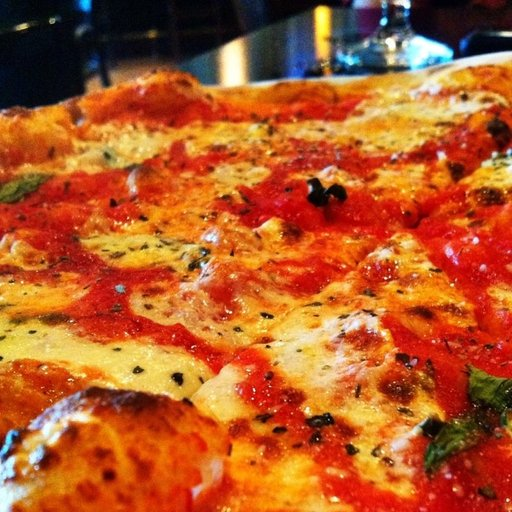

In [15]:
import random
from PIL import Image

random.seed(42)
image_path_list = list(image_path.glob('*/*/*.jpg'))
image_path_list[:5]

# Load in and view a random image
random_image_path = random.choice(image_path_list)
random_image_path

# Get the class names
class_names = random_image_path.parent.name
class_names

# Load in the image
img = Image.open(random_image_path)

# Print some metadata about the image
print(f'Image size: {img.size}')
print(f'Image format: {img.format}')
print(f'Image mode: {img.mode}')
print(f'Image class name: {class_names}')
img

(512, 512, 3)

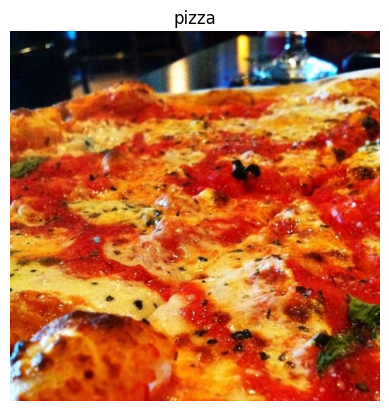

In [18]:
# Visualizing the image via matplotlib
import matplotlib.pyplot as plt
import numpy as np

plt.imshow(img)
plt.title(class_names)
plt.axis(False)

img_array = np.array(img)
img_array.shape

# 3. Transforming the data
Before we can use our data:

1. Turn data into tensors
2. Turn it into a `torch.utils.data.Dataset` and `DataLoader`

In [21]:
from torch.utils.data  import DataLoader
from torchvision import datasets, transforms

# Write a transform fro image
data_transform = transforms.Compose([
    # Resize the image to 64x64
    transforms.Resize((64, 64)),
    # Flip the image horizontally with a probability of 0.5
    transforms.RandomHorizontalFlip(p=0.5),
    # Convert the image to a tensor
    transforms.ToTensor()
])
data_transform(img).shape

torch.Size([3, 64, 64])

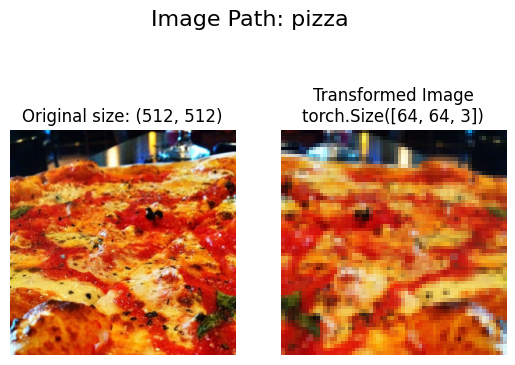

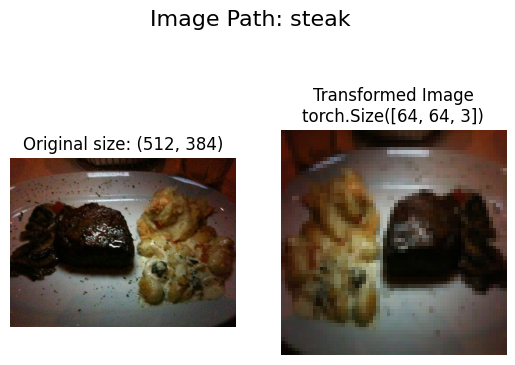

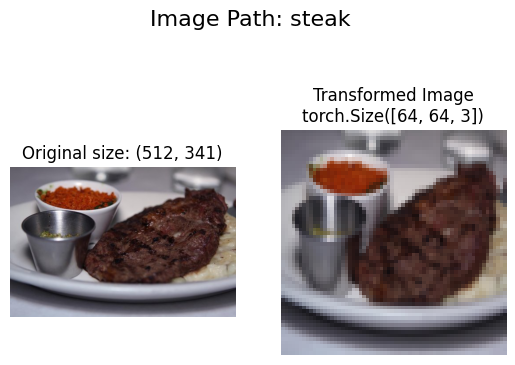

In [26]:
def plot_transformed_image(image_path, transform, n=3, seed=42):
    """Selects random images from images_path and compare to the original one"""
    if seed:
        random.seed(seed)
    random_image_path = random.sample(image_path_list, k=n)
    for image_path in random_image_path:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original size: {f.size}")
            ax[0].axis(False)

            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed Image\n{transformed_image.shape}")
            ax[1].axis(False)
            
            fig.suptitle(f"Image Path: {image_path.parent.stem}", fontsize=16)
plot_transformed_image(image_path_list, transform=data_transform, n=3, seed=42)

# 4. Option 1: Loading image data using `ImageFolder`

`torchvision.dataset.ImageFolder`

In [27]:
# Using ImageFolder to create datasets
train_data = datasets.ImageFolder(
    root=train_dir,
    transform=data_transform, # a transform we created earlier
    target_transform=None # no target transform
)
test_data = datasets.ImageFolder(
    root=test_dir,
    transform=data_transform, # a transform we created earlier
)
train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [29]:
# Get class names as list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [30]:
# Get class names as dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [31]:
# Check the length of out dataset
len(train_data), len(test_data)

(225, 75)

In [32]:
train_data.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [38]:
# Index on the train_data dataset
img,label = train_data[0][0], train_data[0][1]
print(f'Image tensor:\n{img}')
print(f'Label: {label}')
print(f'Class name: {class_names[label]}')
print(f"Image tensor shape: {img.shape}")
print(f"Image data type: {img.dtype}")

Image tensor:
tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.01

In [35]:
class_names[label]

'pizza'

original shape: torch.Size([3, 64, 64]) | permuted shape: torch.Size([64, 64, 3])
permuted image data type: torch.float32


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

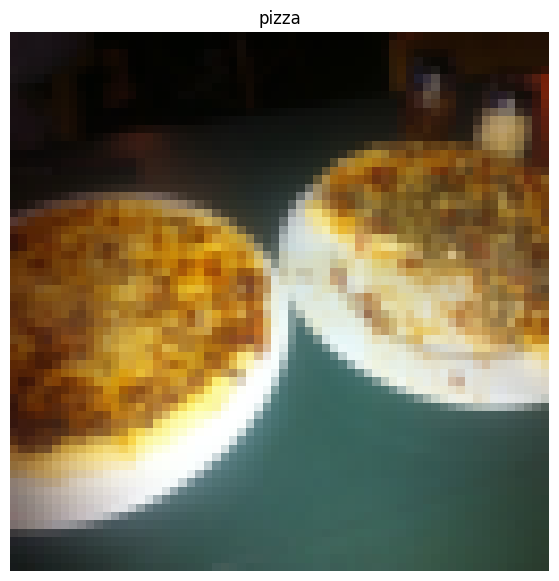

In [39]:
# Rearrange the order of dimensions
img_permuted = img.permute(1, 2, 0)

# Print out different shapes
print(f"original shape: {img.shape} | permuted shape: {img_permuted.shape}")
print(f"permuted image data type: {img_permuted.dtype}")

# Plot the images
plt.figure(figsize=(10,7))
plt.imshow(img_permuted)
plt.title(class_names[label])
plt.axis(False)

# 4.1 Turn loaded images into `DataLoader`s

It helps us to iterate and change the batchsize as well

In [47]:
# Turn train and test datasets into dataloaders
BATCH_SIZE = 1
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)
test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x162db40d0>,
 <torch.utils.data.dataloader.DataLoader at 0x162e849d0>)

In [48]:
img, label = next(iter(train_dataloader))

# Batch size will now be 1
print(f'Image batch shape: {img.shape} | Label batch shape: {label.shape}')

Image batch shape: torch.Size([1, 3, 64, 64]) | Label batch shape: torch.Size([1])


# 5 Option 2: Loading Image Data with a Custom `Dataset`

## Pros:
* Can create a `Dataset` out of almost anything
* Not limited to PyTorch prebuilt `Dataset` functions

## Cons:
* Even though you could create `Dataset` out of almost anything, it doesn't mean it will work...
* Using a custom `Dataset` ofetn results in us writing more code, which could be prone to errors or performance issues

In [49]:
import pathlib
from torch.utils.data import Dataset
from typing import Tuple, Dict, List

In [50]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})